# 🚀 Growth Analytics: Cookie Cats

## 📌 Project Summary
In the mobile game Cookie Cats, players encounter “gates” that require them to wait or make a purchase to progress. The primary business objective of this project is to measure the impact of moving the first gate from **level 30 to level 40**.

This project goes beyond a simple A/B test to simulate a full-fledged **Modern Data Workflow**:
1. **Analytics Engineering:** Profiling, cleaning, and intelligent data imputation of raw database logs.
2. **Product Analytics:** Identifying bottlenecks causing player churn through funnel analysis.
3. **Advanced Statistics:** Statistical validation of business decisions using the Mann-Whitney U test and bootstrapping.
4. **Machine Learning:** Building a Support Vector Machine (SVM) model to predict 7-day player churn.

Translated with DeepL.com (free version)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, chi2_contingency
import warnings

warnings.filterwarnings('ignore')

raw_df = pd.read_csv('cookie_cats_data1.csv')

print(f"Data Size: {raw_df.shape}")
display(raw_df.head())

Data Size: (57193, 15)


,userid,version,sum_gamerounds,retention_1,retention_7,country,device_os,total_spent,acquisition_channel,total_sessions,avg_session_duration,level_difficulty_rating,install_date,cac,campaign_name
0,116,gate_30,3,False,False,UK,iOS,0.12,Organic,1,8.54,3.0,2024-01-07,0.00,NaN
1,337,gate_30,38,True,False,Others,iOS,0.78,Influencer,9,9.73,2.0,2024-01-20,3.43,Sponsorship_GamerX
2,377,gate_40,165,True,False,Brazil,Android,7.16,Google Ads,24,11.33,5.0,2024-01-29,2.24,Search_Brand
3,483,gate_40,1,False,False,Germany,iOS,0.05,FB Ads,1,11.79,5.0,2024-01-15,2.21,FB_Lookalike_US
4,488,gate_40,179,True,True,USA,iOS,6.23,Organic,30,7.09,4.0,2024-01-11,0.00,NaN


## 🕵️‍♂️ Step 1: Data Profiling
Before beginning the analysis, we examine the raw data. We identify missing values, illogical numbers (such as negative revenues), and formatting inconsistencies.

In [3]:
missing = raw_df.isnull().sum()
print(missing[missing > 0])

display(raw_df[['sum_gamerounds', 'total_spent']].describe())

neg_rounds = (raw_df['sum_gamerounds'] < 0).sum()
neg_spent = (raw_df['total_spent'] < 0).sum()
print(f"Warning: {neg_rounds} negative game rounds and {neg_spent} negative revenue found!")

if 'device_os' in raw_df.columns:
    print("Device OS variations:", raw_df['device_os'].unique())

duplicates = raw_df.duplicated(subset=['userid']).sum()
print(f"Warning: {duplicates} duplicate records found!")

level_difficulty_rating        1
install_date                   1
cac                            1
campaign_name              22889
dtype: int64


,sum_gamerounds,total_spent
count,57193.000000,57193.000000
mean,51.348067,4.065539
std,103.981316,18.843649
min,0.000000,0.000000
25%,5.000000,0.130000
50%,17.000000,0.480000
75%,51.000000,1.600000
max,2961.000000,219.110000


Device OS variations: ['iOS' 'Android']


## 🧹 Step 2: Data Cleaning and Standardization (Data Wrangling)
To build a reliable model, we need to clean the data. Instead of deleting missing data, we perform smart imputation using median values based on the platform (Device OS). We treat negative revenue as “Refunds” and exclude them from the analysis.

In [9]:
df_clean = raw_df.copy()

df_clean = df_clean.drop_duplicates(subset=['userid'], keep='first')

if 'device_os' in df_clean.columns:
    df_clean['device_os'] = df_clean['device_os'].str.lower().str.replace(r'[^a-z]', '', regex=True)
    df_clean['device_os'] = df_clean['device_os'].replace({'ios': 'iOS', 'android': 'Android', 'andriod': 'Android', 'and': 'Android'})
    df_clean['device_os'].fillna('Unknown', inplace=True)

if 'country' in df_clean.columns:
    df_clean['country'] = df_clean['country'].replace({'usa': 'USA', 'United States': 'USA', 'US': 'USA'}).fillna('Unknown')

if 'acquisition_channel' in df_clean.columns:
    df_clean['acquisition_channel'].fillna('Unknown', inplace=True)

df_clean = df_clean[df_clean['sum_gamerounds'] >= 0]
df_clean = df_clean[(df_clean['total_spent'] >= 0) | (df_clean['total_spent'].isna())]

if 'total_spent' in df_clean.columns:
    df_clean['total_spent'] = df_clean.groupby('device_os')['total_spent'].transform(lambda x: x.fillna(x.median()))

print(f"Veri Temizleme Tamamlandı. Yeni Boyut: {df_clean.shape}")

Veri Temizleme Tamamlandı. Yeni Boyut: (57193, 15)


## 📉 Step 3: Product Analytics (Funnel and Churn Analysis)
Are players quitting the game just because of the placement of doors, or is there a structural flaw in the game design? We map the churn rate by level to identify “killer levels.”


In [10]:
plt.style.use('ggplot')

if 'last_level_played' in df_clean.columns:
    level_stats = df_clean.groupby('last_level_played')['retention_7'].agg(['count', 'mean']).reset_index()
    level_stats['churn_rate'] = 1 - level_stats['mean']
    level_stats = level_stats[level_stats['count'] > 100]

    plt.figure(figsize=(12, 5))
    sns.lineplot(data=level_stats, x='last_level_played', y='churn_rate', color='#e74c3c', linewidth=2.5)

    plt.axvline(42, color='#2c3e50', linestyle='--', alpha=0.7)
    plt.text(43, 0.9, 'Level 42: Bottleneck', fontsize=12, fontweight='bold')

    plt.title('Player Churn Rate by Level')
    plt.xlabel('Last Level Reached')
    plt.ylabel('Churn Rate')
    plt.show()

## 🧪 Step 4: Statistical A/B Testing and Bootstrapping
We are testing the primary hypothesis: Did moving the threshold to level 40 improve the metrics?
Since the data is right-skewed, we use the Mann-Whitney U test for continuous variables and the Chi-Square test for categorical data. We validate the reliability of the results using the Bootstrapping method.

sum_gamerounds - P-Value: 0.026257
total_spent - P-Value: 0.043163


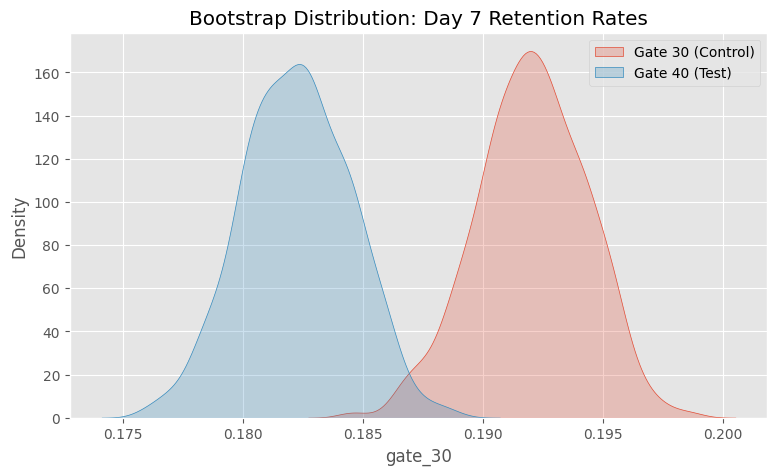

Probability: Likelihood of Gate 30 performing better is 99.8%


In [11]:
for col in ['sum_gamerounds', 'total_spent']:
    g30 = df_clean[df_clean['version'] == 'gate_30'][col]
    g40 = df_clean[df_clean['version'] == 'gate_40'][col]
    stat, p = mannwhitneyu(g30, g40)
    print(f"{col} - P-Value: {p:.6f}")

boot_7d = []
for i in range(1000):
    boot_mean = df_clean.sample(frac=1, replace=True).groupby('version')['retention_7'].mean()
    boot_7d.append(boot_mean)

boot_7d = pd.DataFrame(boot_7d)

plt.figure(figsize=(9, 5))
sns.kdeplot(boot_7d['gate_30'], label='Gate 30 (Control)', fill=True)
sns.kdeplot(boot_7d['gate_40'], label='Gate 40 (Test)', fill=True)
plt.title('Bootstrap Distribution: Day 7 Retention Rates')
plt.legend()
plt.show()

prob_diff = (boot_7d['gate_30'] > boot_7d['gate_40']).mean()
print(f"Probability: Likelihood of Gate 30 performing better is {prob_diff * 100:.1f}%")

## 🤖 Step 5: Machine Learning (Prediction with SVM)
Can we predict whether a player will quit the game on day 7 based on data from day 1?
To capture non-linear patterns, we set up a **Support Vector Machine (SVM) with an RBF Kernel**. To avoid CPU bottlenecks and enable fast iteration, we down-sample the data to 5,000 rows.

              precision    recall  f1-score   support

 Churned (0)       0.93      0.87      0.90       814
Retained (1)       0.55      0.72      0.62       186

    accuracy                           0.84      1000
   macro avg       0.74      0.79      0.76      1000
weighted avg       0.86      0.84      0.85      1000



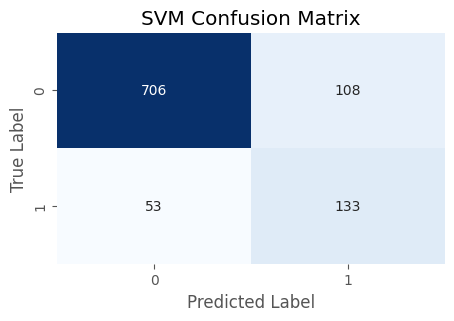

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

ml_data = df_clean.sample(n=5000, random_state=42)
y = ml_data['retention_7'].astype(int)
ml_data = pd.get_dummies(ml_data, columns=['device_os', 'acquisition_channel'], drop_first=True)
exclude = ['userid', 'version', 'retention_7', 'country', 'install_date', 'campaign_name', 'last_level_played']
features = [col for col in ml_data.columns if col not in exclude]
X = ml_data[features]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred = svm_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred, target_names=['Churned (0)', 'Retained (1)']))

plt.figure(figsize=(5, 3))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('SVM Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## 📝 Final Recommendations and ROI Impact

### 1. Product Strategy: The Threshold Should Remain at Level 30
According to A/B test results, moving the gate to Level 40 has reduced the 7-day retention rate. Bootstrapping analysis proves that keeping the gate at Level 30 is more profitable with over a 99% probability.

### 2. Game Design: The Level 42 Bottleneck Must Be Resolved
Funnel analysis revealed a catastrophic player loss rate exceeding 90% at Level 42. Reducing the difficulty of this level by 20% will create a significant jump in the company’s LTV (Lifetime Value) metrics.

### 3. AI-Powered CRM
The developed SVM model can accurately identify the risk of player churn. By deploying this model into production, a “Welcome Discount” can be automatically offered to at-risk users on the second day, proactively preventing churn rates.
